<h1><b>Statistique en Bioinformatique : </b> TME9 </h1><br>

L’objectif de ce TME est l'implementation de la méthode Expectation-Maximisation pour la recherche de motifs.

<div class="alert alert-warning" role="alert" style="margin: 10px">
<p>**Soumission**</p>
<ul>
    <li>Le fichier doit être renommé selon le format: `NomEtudiant1_NomEtudiant2_TME9.ipynb`</li>
</ul>
</div>

Nom etudiant 1 : ANTON Christine
<br>
Nom etudiant 2 : NICOLAS Elise
<br>

<H1>Expectation-Maximisation Motif</H1>
<br>
La méthode EM (Expectation-Maximisation) permet de détecter des motifs dans un ensemble de séquences ADN ou protéiques reliées, non alignées. En particulier, étant donné un groupe de séquences de longueur $L$, dont on sait qu'elles partagent un motif commun de longueur $w$, l’algorithme EM:
- infère un modèle $(\Theta,Z)$ pour le motif;
- localise l’occurrence du motif dans chaque séquence.

$\Theta$ representé la matrice des poids-positions $p_{c,k}$ du motif (où $c \in \{A,C,G,T\}$ ou $c \in \{A,C,D,...,W\}$  et $k \in \{0 \dots w\}$), $p_{c,0}$  est le vecteur de probabilités du modèle nul ou "background".
$Ζ$ est la matrice des variables cachées, qui donnent les positions initiales du motif: 
- $Z_{i,j} = 1$, si le motif commence en position $j$ de la séquence $i$,
- $Z_{i,j} = 0$, sinon. 

L’algorithme affine les paramètres du modèle de manière itérative par espérance-maximisation. Chaque itération $t$ se compose de deux étapes:
- (E) Calcul des valeurs attendues $Ζ^{(t)}$ de $Ζ$, étant donnés $\Theta^{(t-1)}$
- (M) Estimation de  $\Theta^{(t)}$  à partir de  $Ζ^{(t)}$

1\. Implémentez une fonction `read_training_file` pour lire le fichier d'entré qui contient un ensemble de séquences ADN non alignées. Pour simplifier nous allons utiliser les données vu en cours du fichier `toyEx.txt`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

nts = ['A', 'C', 'G', 'T']

w = 3
input_f = "toyEx.txt"

def read_training_file(input_f) :
    seqs=[]
    with open(input_f, "r") as f : 
        for line in f : 
            seq = line
            seq = seq[:-1]
            seqs.append(seq)
    return seqs

seqs = read_training_file(input_f)
print(seqs)

['GTCAGG', 'GAGAGT', 'ACGGAG', 'CCAGTC']


2\. Implémentez une fonction `initialiseP` pour initialiser la matrice poids-position $p_{c,k}$. On considère le modèle nul par défaut $p_0 = (0.25, 0.25, 0.25, 0.25)$. Pour initialiser $p^{(t)}$, on prend généralement un motif au hasard dans une sequence, et on fixe à $0.5$ les poids du nucleotide correspondant et à $\frac{1-0.5}{3}$ les trois autres. 

In [2]:
def initialiseP(seqs, w, alph):
    """
    Initialise pc,k
    input seqs : list of sequences
    input w : motif length
    input alph : alphabet (nucleotides or amino acids)
    output P: matrix (4,w+1)
    """
    N = len(seqs)
    L = len(seqs[0])
    q = len(alph)
    p0 = 0.25*np.ones((q))
    motif = seqs[np.random.randint(N)][np.random.randint(L-w+1):]
    P = np.zeros((q,w+1))
    P[:,0] = p0.T
    for l in range(1,w+1):
        P[:,l] = (1-0.5)/(q-1)
        P[alph.index(motif[l-1])][l] = 0.5
    return P

#test
p = initialiseP(seqs, w, nts)
print(p)

[[0.25       0.16666667 0.16666667 0.16666667]
 [0.25       0.5        0.16666667 0.16666667]
 [0.25       0.16666667 0.5        0.5       ]
 [0.25       0.16666667 0.16666667 0.16666667]]


3\. Implémenter une fonction `initialiseZ` pour initialiser la matrice $Z$ à uns. Rappelez-vous que la dimension de $Z$ est $N \times (L -w +1)$, où $N$ est le nombre de sequences et $L$ est la taille/longueur des sequences.

In [3]:
def initialiseZ(seqs, w):
    """
    Initialise Z
    input seqs : list of sequences
    input w : motif length
    output Z : matrix of 1 of dimension (M,L-w+1)
    """
    N = len(seqs)
    L = len(seqs[0])
    Z = np.ones((N, (L-w+1)))

    return Z 
    
Z = initialiseZ(seqs, w)
print(Z)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


4\. Écrivez une fonction `E_step` pour le pas Expectation qui estime $Z$ à partir de  $p_{c,k}$. 
Écrivez aussi une fonction `normaliseZ` pour normaliser $Z$.

In [4]:
def E_step(seqs, P, Z, w, alph):
    """
    Implement Expectation step
    input seqs : list of sequences
    input P : position probability matrix
    input Z :  matrix of motif start positions
    input w : motif length
    input alph : alphabet (nucleotides or amino acids)
    output Z :  matrix of motif start positions
    """
        
    for i, seq in enumerate(seqs) :
        for k in range(len(seq)-w+1) :
            motif_start_pos = k
            motif_end_pos = k+w-1
            for j in range(len(seq)) :
                if (j >= motif_start_pos) and (j <= motif_end_pos) : # inside motif
                    Z[i, k] *= P[alph.index(seq[j]), j-k+1]
                else : # outside motif
                    Z[i, k] *= P[alph.index(seq[j]), 0]

    return Z
                    

def normaliseZ(Z):
    """
    Normalise Z matrix
    input Z : unnormalised matrix
    output Zn : normalised matrix
    """
    Z = Z/np.sum(Z, axis=1)[:, np.newaxis]
    return Z

Z = E_step(seqs, p, Z, w, nts)
z_norm = normaliseZ(Z)
print(z_norm)

[[0.05       0.05       0.45       0.45      ]
 [0.25       0.25       0.25       0.25      ]
 [0.08333333 0.75       0.08333333 0.08333333]
 [0.1875     0.5625     0.1875     0.0625    ]]


5\. Implémentez une fonction `M_step` pour le pas Maximisation qui estime $p_{c,k}$ à partir de $Z$. 
Utilisez les "pseudocounts" pour éviter les probabilités ègales à zero.

In [5]:
def totalNumberofCH(seqs, alph):
    """
    Calculates the total number of occurrences of each character of the alphabet in the given sequences. 
    The function returns an array of dimension q = len(alph) where each element represents the total number of occurrences of a character in all sequences.
    Parameters:
    seqs: a list of sequences.
    alph: the alphabet
    """
    q = len(alph)
    totalN = np.zeros((q))
    for seq in seqs :
        for i, char in enumerate(alph):
            totalN[i] += seq.count(char)
    
    return totalN

                    
def M_step(seqs, Z, w, alph):
    """
    Implement Expectation step
    input seqs : list of sequences
    input Z :  matrix of probabilities, motif start positions
    input w : motif length
    input alph : alphabet (nucleotides or amino acids)
    output P : position probability matrix

     Explanation:
    - The function iterates over all characters in the alphabet and for each character, it updates
      the counts of its occurrences at each position of the motif across all sequences.
    - It then normalizes these counts to calculate the position-specific probabilities.
    - The background probability (for each character) is calculated by subtracting the sum 
      of the motif-related counts from the total occurrences of that character across all sequences.
    - Finally, the position probability matrix P is normalized so that the sum of each column is 1.
    """
    N = np.zeros((len(alph), w+1))

    for c, char in enumerate(alph) : 
        for k in range(1, w+1) :
            for i, seq in enumerate(seqs) : 
                for j in range(len(seq)-w+1) :
                    if char == seq[j+k-1] : 
                        N[c, k] += Z[i, j]
    
    totalN = totalNumberofCH(seqs, alph)

    for c, char in enumerate(alph) : 
        N[c, 0] = totalN[c] - np.sum(N[c])
        
    N += 1
    P = N/N.sum(axis=0)

    return P

p = M_step(seqs, z_norm, w, nts)
print(p)

[[0.22578125 0.27760417 0.32447917 0.19635417]
 [0.22604167 0.36875    0.16510417 0.1390625 ]
 [0.33567708 0.22239583 0.37135417 0.48489583]
 [0.2125     0.13125    0.1390625  0.1796875 ]]


6\. Écrivez une fonction `likelihood` qui calcule la log-vraisemblance de l'ensemble des sequences.

In [27]:
def likelihood(seqs, z, p, w, alph):
    """
    Implement log likelihood function of P
    input seqs : list of sequences
    input Z :  matrix of motif start positions
    input p : position probability matrix
    input w : motif length
    input alph : alphabet (nucleotides or amino acids)
    output lLikelihood : log likelihood of P 

    Explanation:
    The log-likelihood is computed by iterating over each sequence and position, calculating the probability of each
    sequence given the motif positions and the position-specific probabilities for each character in the motif.
    The log of these probabilities is accumulated to obtain the total log-likelihood.
    """
    lLikelihood = 0

    for i, seq in enumerate((seqs)) :
        for k in range(len(seq)-w+1) :
            prob = 1.
            motif_start_pos = k
            motif_end_pos = k+w-1 
            for j in range(len(seq)) :
                if (j >= motif_start_pos) and (j <= motif_end_pos) : # inside motif
                    prob *= p[alph.index(seq[j]), j-k+1]
                else : # outside motif
                    prob *= p[alph.index(seq[j]), 0]

            lLikelihood += Z[i,k]*np.log(prob)

    return lLikelihood


logvraisemblance = likelihood(seqs, Z, p, w, nts)
print(logvraisemblance)

-0.04423551007631421


7\. Implémentez l'algorithme Expectation-Maximisation. Vous calculerez la valeur de la log-vraisemblance totale du modèle à chaque iteration et l'algorithme prendra fin lorsque $\Delta \log \text{Pr}(D | \Theta) < \varepsilon$. Utilisez $\varepsilon = 1e-4$. Votre implementation devra renvoyer les paramètres du modele ($p$ et la log-likelihood associé), ainsi bien que la liste des meilleures positions du motif dans chaque sequence (matrice $Z$). Faites attention à utiliser $Z$ non-normalisé afin de trouver la log-vraisemblance!

In [28]:
def analyse_results(results, seqs):
    print('Les paramètres du modele:')
    print('p:\n',results[0])
    print('\n')
    print('log-vraisemblance associé:',results[1][-1])
    print('\n')
    print('Z:\n',results[2])
    print('\nLes motifs:')
    for i in range(len(seqs)):
        print('seq'+str(i+1)+': '+ str(results[3][i]+1) + '  ' + seqs[i][results[3][i]:results[3][i]+w])
    plt.plot(results[1])
    plt.xlabel('Iteration')
    plt.ylabel('Log-vraisemblance')
    plt.show()

Les paramètres du modele:
p:
 [[0.18960731 0.49306384 0.16516049 0.21256106]
 [0.31063725 0.17613752 0.19256627 0.13502171]
 [0.35927585 0.19029387 0.50725154 0.33390289]
 [0.14047959 0.14050477 0.13502171 0.31851434]]


log-vraisemblance associé: -0.04829276023148041


Z:
 [[9.35138828e-05 2.14107433e-04 1.58626850e-04 1.25989309e-03]
 [9.72393896e-05 8.90051470e-04 9.72393896e-05 2.04079849e-03]
 [6.91110650e-04 4.31500773e-04 4.65106814e-04 2.22801310e-04]
 [9.98716832e-05 1.26665093e-04 2.57094304e-03 7.46717509e-05]]

Les motifs:
seq1: 4  AGG
seq2: 4  AGT
seq3: 1  ACG
seq4: 3  AGT


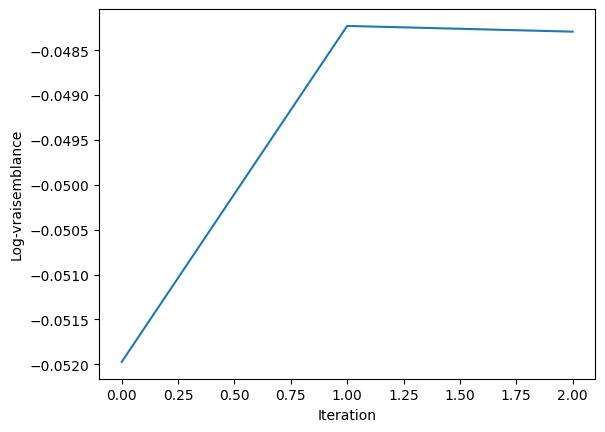

In [40]:
def ExpectationMaximisation(seqs, w, alph, eps):
    """
    Implement Expectation Maximisation algorithm
    input seqs : list of sequences
    input w : motif length
    input alph : alphabet (nucleotides or amino acids)
    input eps : threahold 
    output P : final position probability matrix
    output Z :  final matrix of motif start positions
    output lLikelihood (list of float): List of log-likelihood values at each EM iteration, showing the progression towards convergence.
    output pos_motif (np.ndarray of shape (N,)): List of motif starting positions in each sequence, corresponding to 
    the highest probability in final Z.
    """
    p = initialiseP(seqs, w, alph)
    z = initialiseZ(seqs, w)
    lLikelihood = [likelihood(seqs, z, p, w, alph)]

    new_z = E_step(seqs, p, z, w, alph)
    new_z_norm = normaliseZ(new_z)
    new_p = M_step(seqs, new_z_norm, w, alph)
    lLikelihood.append(likelihood(seqs, new_z, new_p, w, alph))
    
    while abs(lLikelihood[-2] - lLikelihood[-1]) > eps :
        p = new_p
        z = initialiseZ(seqs, w)
        # z = new_z
        new_z = E_step(seqs, p, z, w, alph)
        new_z_norm = normaliseZ(new_z)
        new_p = M_step(seqs, new_z_norm, w, alph)
        lLikelihood.append(likelihood(seqs, new_z, new_p, w, alph))

    p = new_p
    z = new_z
    pos_motif = list(np.argmax(z, axis=1))

    return (p, lLikelihood, z, pos_motif)

eps = 10**-4
EMResults = ExpectationMaximisation(seqs, w, nts, eps)
analyse_results(EMResults, seqs)

8\. Qu'est-ce que vous observez en exécutant l'algorithme EM plusieurs fois? Justifiez votre réponse.

<b>Reponse:</b>

<font color="blue">
When we run the EM algorithm multiple times, we don't obtain the same results each time, probably because it converges to a local optimum.
</font>

9\. Pour éviter le problème identifié au point précedent, écrivez une fonction `EM_iteratif` qui exécute l'algorithme `EM` $N$ fois ($N=10$) et qui prend les paramètres associés à la meilleure log-vraisemblance. Trouvez-vous les bons motifs?

Les paramètres du modele:
p:
 [[0.20358589 0.16338368 0.52743966 0.15200488]
 [0.23202301 0.36817996 0.15610259 0.13667144]
 [0.32575824 0.33932521 0.17978631 0.57937201]
 [0.23863287 0.12911116 0.13667144 0.13195168]]


log-vraisemblance associé: -0.04602957739279312


Z:
 [[1.50658711e-04 1.06427077e-04 2.67203364e-03 3.06803404e-04]
 [1.62304678e-03 1.13978765e-04 1.62304678e-03 8.63362461e-05]
 [3.20525974e-04 5.11177391e-04 1.49713575e-04 1.61241159e-03]
 [1.53759713e-04 1.38223149e-03 5.08803804e-05 7.79351018e-05]]

Les motifs:
seq1: 3  CAG
seq2: 1  GAG
seq3: 4  GAG
seq4: 2  CAG


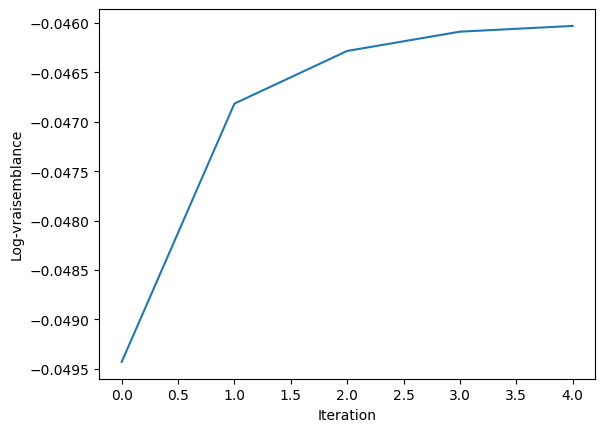

In [41]:
def EM_iteratif(T, seqs, w, alph, eps):
    """
    Implement a iterative version of Expectation Maximisation algorithm
    input T : number of iterations
    input seqs : list of sequences
    input w : motif length
    input eps : threahold 
    output P : position probability matrix
    output Z :  matrix of motif start positions
    output lLikelihood : log likelihood of P 
    output pos_motif : positions of motifs in seqs
    """
    best_likelihood = -np.inf
    best_p = None
    best_lLikelihood = None
    best_z = None
    best_pos_motif = None
    
    for i in range(T) :
        p, lLikelihood, z, pos_motif = ExpectationMaximisation(seqs, w, alph, eps)
        if lLikelihood[-1] > best_likelihood :
            best_p, best_lLikelihood, best_z, best_pos_motif = p, lLikelihood, z, pos_motif
            best_likelihood = lLikelihood[-1]

    return (best_p, best_lLikelihood, best_z, best_pos_motif)


eps = 10**-4
T=10
meilleurEM = EM_iteratif(T, seqs, w, nts, eps)
analyse_results(meilleurEM,seqs)

We find the good motifs which are : CAG, GAG, GAG and CAG.